In [2]:
import numpy
import matplotlib
import astropy
import astroplan

print(f"NumPy: {numpy.__version__}")
print(f"Matplotlib: {matplotlib.__version__}")
print(f"Astropy: {astropy.__version__}")
print(f"Astroplan: {astroplan.__version__}")

NumPy: 1.21.6
Matplotlib: 3.5.3
Astropy: 4.3.1
Astroplan: 0.10.1


In [93]:
import sys
print(f"Python version: {sys.version}")

Python version: 3.7.12 | packaged by conda-forge | (default, Oct 26 2021, 06:08:21) 
[GCC 9.4.0]


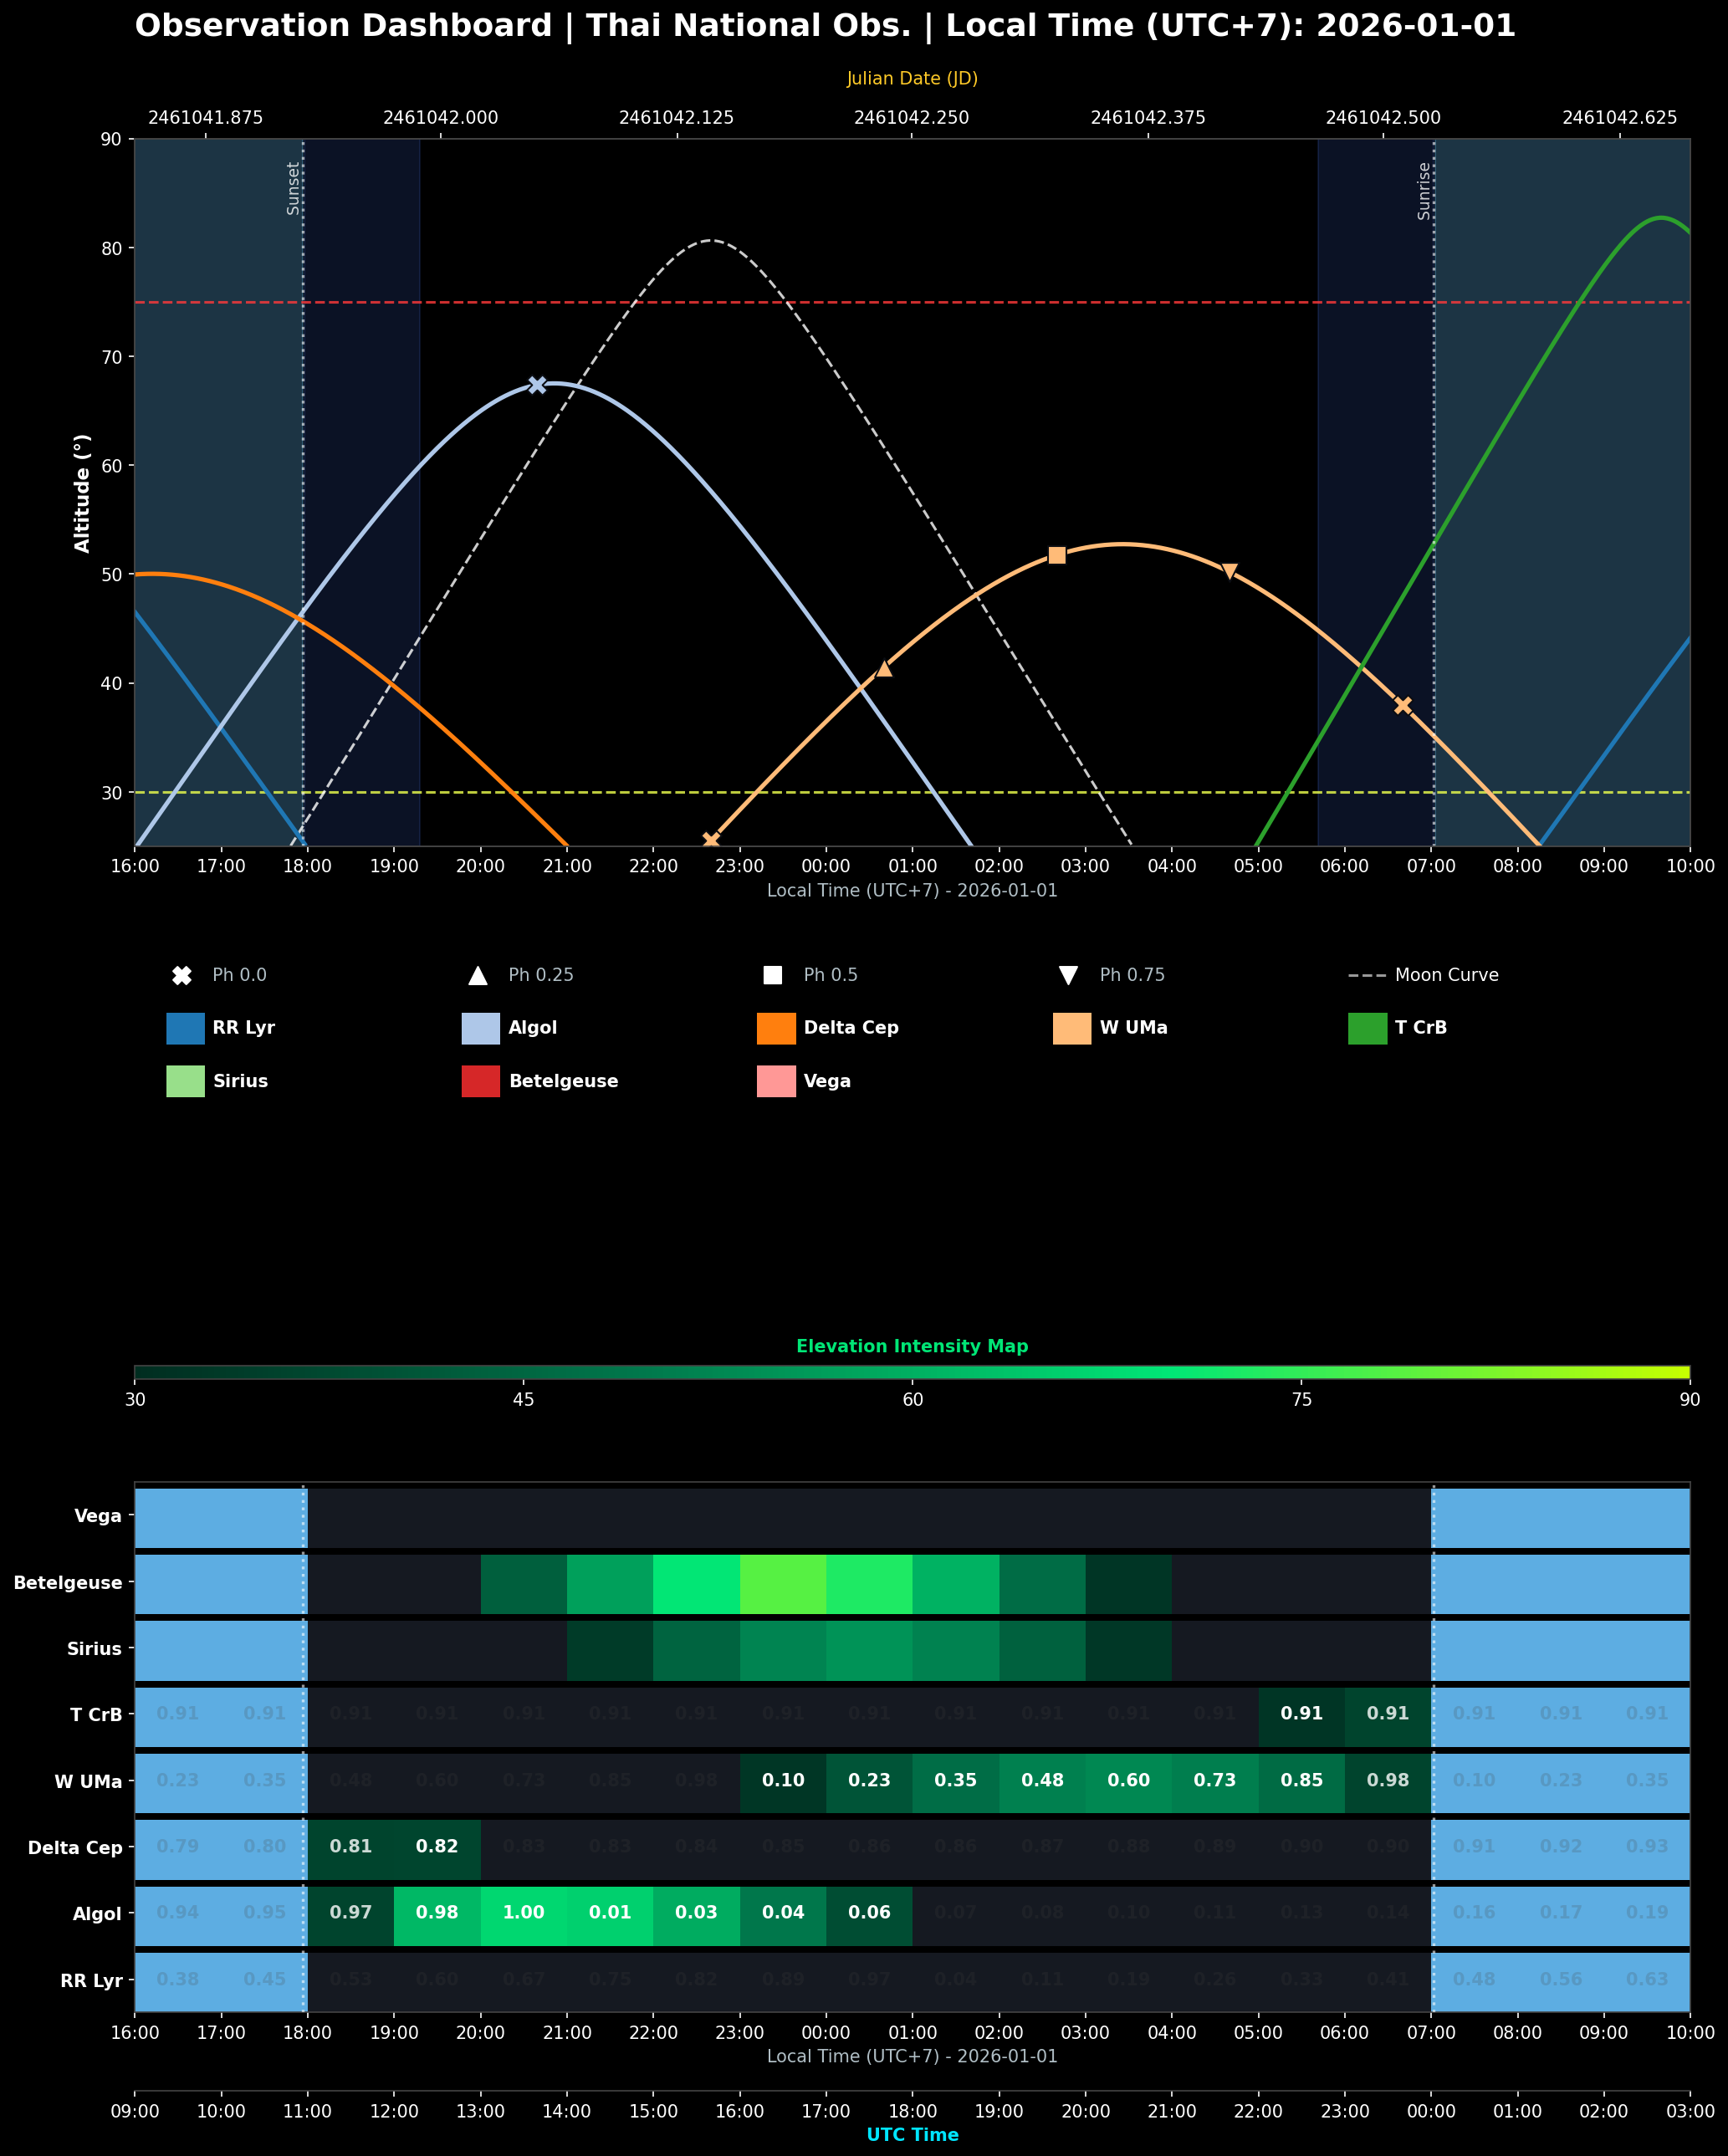

[SUCCESS] Ephemeris and observation window data exported to: /media/chaoxu/Ubda/Object/Obs/TNO_2026-01-01_Observation_Plan.txt


In [18]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.colors as mcolors
import warnings
from astropy import units as u
from astropy.time import Time
from astropy.coordinates import EarthLocation, SkyCoord, get_sun, get_moon
from astroplan import Observer, FixedTarget
from astropy.utils.exceptions import AstropyWarning
from matplotlib.patches import Rectangle
from matplotlib.colors import LinearSegmentedColormap

# 忽略 Astropy 的警告信息 / Ignore Astropy warning messages
warnings.simplefilter('ignore', category=AstropyWarning)

def get_phase(jd, t0, period):
    # 如果周期或历元为 0，返回 nan / Return nan if period or epoch is 0
    if not period or not t0: return np.nan
    return ((jd - t0) / period) % 1.0

def find_phase_crossings(phases, target_phase):
    # 寻找特定相位跨越的索引 / Find indices where specific phase crossings occur
    crossings = []
    for k in range(len(phases) - 1):
        p1, p2 = phases[k], phases[k+1]
        if np.isnan(p1) or np.isnan(p2): continue
        if p2 < p1: 
            if target_phase >= p1 or target_phase < p2: crossings.append(k)
        else: 
            if p1 <= target_phase < p2: crossings.append(k)
    return crossings

def plot_final_smart_phase_dashboard(obs_location, target_list, obs_date, alt_limit=75, max_display=5):
    """
    动态时区自适应版：生成可视化观测面板
    Dynamic timezone adaptive version: Generate visual observation dashboard
    """
    bg_color = '#0B0D12'        
    plt.rcParams['figure.facecolor'] = bg_color
    plt.rcParams['axes.facecolor'] = bg_color
    plt.style.use('dark_background') 

    # 获取当前台站的 UTC 偏移量，默认回退为 8 / Get the UTC offset of the current station, default fallback is 8
    offset_hrs = obs_location.get('utc_offset', 8)

    location = EarthLocation(lon=obs_location['lon'] * u.deg, 
                             lat=obs_location['lat'] * u.deg, 
                             height=obs_location['height'] * u.m)
    # 移除固定的 timezone 参数，完全依赖数学运算处理时间 / Remove fixed timezone parameter, rely entirely on math for time conversion
    obs_site = Observer(location=location, name=obs_location['name'])

    # --- 时间设置 / Time Settings ---
    start_time_local_str = f"{obs_date} 16:00:00"
    start_time_local_obj = Time(start_time_local_str) 
    
    # 动态转换：本地时间转 UTC / Dynamic conversion: Local time to UTC
    start_time_utc = start_time_local_obj - offset_hrs * u.hour
    
    time_grid_dense = start_time_utc + np.linspace(0, 18, 1000) * u.hour 
    # 动态转换：UTC 转 本地时间 / Dynamic conversion: UTC to Local time
    local_dense = (time_grid_dense + offset_hrs * u.hour).datetime
    jds = time_grid_dense.jd 
    local_hourly_edges = (start_time_utc + np.arange(0, 19) * u.hour + offset_hrs * u.hour).datetime
    time_grid_mid = start_time_utc + np.arange(0.5, 18.5) * u.hour

    # --- 太阳计算 / Solar Calculations ---
    sun_alt_dense = obs_site.altaz(time_grid_dense, get_sun(time_grid_dense)).alt.value
    idx_0 = np.where(np.diff(np.sign(sun_alt_dense - 0)))[0]
    boundary_times = [local_dense[idx] for idx in idx_0]
    boundary_labels = ['Sunset' if idx < len(sun_alt_dense)/2 else 'Sunrise' for idx in idx_0]

    moon_alt_dense = obs_site.altaz(time_grid_dense, get_moon(time_grid_dense)).alt.value

    # 配色 / Color Palette
    night_cmap = LinearSegmentedColormap.from_list('iris_night', ['#002D20', '#007A4D', '#00E676', '#C6FF00'])
    day_color = '#5DADE2' 
    color_cycle = plt.cm.tab20.colors 
    special_phases = {0.0: 'X', 0.25: '^', 0.5: 's', 0.75: 'v'} 

    # ================= 布局计算 / Layout Calculations =================
    num_targets = len(target_list)
    num_phases = len(special_phases)
    n_cols = 5
    n_rows = int(np.ceil((num_targets + num_phases + 1) / n_cols))
    
    fig_height = 8 + 1.2 * num_targets + 0.6 * n_rows
    fig = plt.figure(figsize=(16, fig_height), dpi=150)
    gs = fig.add_gridspec(5, 1, height_ratios=[1.6, 0.12 * n_rows, 0.12, 0.03, 1.2], hspace=0.35) 
    
    ax1 = fig.add_subplot(gs[0])
    label_ax = fig.add_subplot(gs[1]) 
    cbar_ax = fig.add_subplot(gs[3]) 
    ax2 = fig.add_subplot(gs[4], sharex=ax1) 

    # ================= 图 1：高度曲线 / Chart 1: Altitude Curve =================
    ax1.set_ylim(25, 90)
    ax1.fill_between(local_dense, 25, 90, where=(sun_alt_dense > 0), color=day_color, alpha=0.3)
    ax1.fill_between(local_dense, 25, 90, where=(sun_alt_dense <= 0) & (sun_alt_dense > -18), color="#4F7EFF", alpha=0.15)
    ax1.axhline(30, color="#EDFF4D", linestyle='--', lw=1.5, zorder=3, alpha=0.8)
    ax1.plot(local_dense, np.where(moon_alt_dense>=25, moon_alt_dense, np.nan), color='#FFFFFF', lw=1.5, linestyle='--', alpha=0.8, zorder=4)
    ax1.axhline(alt_limit, color="#FF3A3A", linestyle='--', lw=1.5, zorder=3, alpha=0.8)

    target_colors = []
    for i, target_info in enumerate(target_list): 
        l_color = color_cycle[i % 20]
        target_colors.append(l_color)
        
        coord = SkyCoord(target_info['ra'], target_info['dec'], unit=(u.hourangle, u.deg))
        target = FixedTarget(coord=coord, name=target_info['name'])
        target_alt = obs_site.altaz(time_grid_dense, target).alt.value
        target_plot_alt = np.where(target_alt >= 25, target_alt, np.nan)
        
        # 仅显示限额数量的目标曲线 / Only display curves for the max_display limit
        if i < max_display:
            ax1.plot(local_dense, target_plot_alt, color=l_color, lw=2.5, zorder=5)
            period = target_info.get('period', 0)
            t0 = target_info.get('t0', 0)
            if period != 0 and t0 != 0:
                phases_dense = get_phase(time_grid_dense.jd, t0, period)
                for p_val, marker in special_phases.items():
                    cross_indices = find_phase_crossings(phases_dense, p_val)
                    for idx in cross_indices:
                        if target_plot_alt[idx] >= 25: 
                            ax1.scatter(local_dense[idx], target_plot_alt[idx], color=l_color, marker=marker, 
                                        s=120 if marker!='X' else 140, edgecolor=bg_color, linewidth=1, zorder=10)

    # 刻度设置 (显示动态时区) / Tick settings (Display dynamic timezone)
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    ax1.xaxis.set_major_locator(mdates.HourLocator(interval=1))
    ax1.tick_params(labelbottom=True) 
    ax1.set_ylabel('Altitude (°)', fontsize=11, fontweight='bold')   
    site_info = f"{obs_location['name']}"
    
    # 动态时区标题 / Dynamic timezone title
    ax1.set_title(f"Observation Dashboard | {site_info} | Local Time (UTC+{offset_hrs}): {obs_date}", 
              loc='left', fontsize=18, fontweight='bold', pad=20, color='white')
    ax1.set_xlabel(f'Local Time (UTC+{offset_hrs}) - {obs_date}', color='#B0BEC5', fontsize=10)

    # JD 轴 / JD Axis
    ax_jd = ax1.twiny()
    ax_jd.set_xlim(ax1.get_xlim())
    jd_indices = np.linspace(0, len(jds)-1, 7, dtype=int)
    ax_jd.set_xticks(mdates.date2num(local_dense[jd_indices]))
    ax_jd.set_xticklabels([f"{jds[idx]:.3f}" for idx in jd_indices])
    ax_jd.set_xlabel('Julian Date (JD)', color='#FFCA28', labelpad=15)

    # ================= 标签网格 / Label Grid =================
    label_ax.axis('off')
    total_legend_items = num_phases + 1 + num_targets
    for idx in range(total_legend_items):
        row = idx // n_cols
        col = idx % n_cols
        x_pos = 0.02 + col * (0.95 / n_cols)
        y_pos = 1.0 - (row + 0.5) * (1.0 / n_rows)
        
        if idx < num_phases:
            p_val = list(special_phases.keys())[idx]
            marker = special_phases[p_val]
            label_ax.scatter(x_pos + 0.01, y_pos, marker=marker, color='white', s=100, transform=label_ax.transAxes)
            label_ax.text(x_pos + 0.03, y_pos, f"Ph {p_val}", transform=label_ax.transAxes, va='center', fontsize=10, color='#B0BEC5')
        elif idx == num_phases:
            label_ax.plot([x_pos, x_pos + 0.025], [y_pos, y_pos], color='#FFFFFF', linestyle='--', lw=1.5, alpha=0.6, transform=label_ax.transAxes)
            label_ax.text(x_pos + 0.03, y_pos, "Moon Curve", transform=label_ax.transAxes, va='center', fontsize=10, color='#FFFFFF')
        else:
            t_idx = idx - num_phases - 1
            rect = Rectangle((x_pos, y_pos - 0.1), 0.025, 0.2, facecolor=target_colors[t_idx], transform=label_ax.transAxes)
            label_ax.add_patch(rect)
            label_ax.text(x_pos + 0.03, y_pos, target_list[t_idx]['name'], transform=label_ax.transAxes, va='center', fontsize=10, fontweight='bold', color='white')

    # ================= Colorbar =================
    norm = mcolors.Normalize(vmin=30, vmax=90)
    cb = fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=night_cmap), cax=cbar_ax, orientation='horizontal')
    cb.set_ticks([30, 45, 60, 75, 90])
    cbar_ax.set_title('Elevation Intensity Map', color='#00E676', fontsize=10, fontweight='bold', pad=8)

    # ================= 图 2：热力图 (无缝衔接) / Chart 2: Heatmap (Seamless) =================
    x_edges = mdates.date2num(local_hourly_edges)
    for i, target_info in enumerate(target_list):
        coord = SkyCoord(target_info['ra'], target_info['dec'], unit=(u.hourangle, u.deg))
        target = FixedTarget(coord=coord, name=target_info['name'])
        period = target_info.get('period', 0)
        t0 = target_info.get('t0', 0)

        for j in range(18): 
            mid_time = time_grid_mid[j]
            alt = obs_site.altaz(mid_time, target).alt.value
            sun = obs_site.altaz(mid_time, get_sun(mid_time)).alt.value
            norm_alt = np.clip((alt - 30) / 60.0, 0, 1)

            if sun > 0: 
                color, text_alpha, text_color = day_color, 0.2, '#444444'
            elif alt >= 30: 
                if sun < -18: 
                    color, text_alpha = night_cmap(norm_alt), 1.0
                    text_color = "#FF0000" if norm_alt > 0.75 else '#FFFFFF' 
                else: 
                    color, text_alpha, text_color = night_cmap(0.1), 0.8, '#FFFFFF'
            else: 
                color, text_alpha, text_color = '#151921', 0.2, '#444444'
            
            rect = Rectangle((x_edges[j], i - 0.5), 
                             (x_edges[j+1]-x_edges[j]), 0.9, facecolor=color, edgecolor='none', zorder=2)
            ax2.add_patch(rect)
            
            if period != 0 and t0 != 0:
                phase_mid = get_phase(mid_time.jd, t0, period)
                ax2.text(x_edges[j] + (x_edges[j+1]-x_edges[j])/2, i, f"{phase_mid:.2f}", 
                         ha='center', va='center', color=text_color, alpha=text_alpha, fontsize=10, fontweight='bold', zorder=5)

    ax2.set_xlim(x_edges[0], x_edges[-1])
    ax2.set_ylim(-0.5, num_targets - 0.5)
    ax2.set_yticks(range(num_targets))
    ax2.set_yticklabels([t['name'] for t in target_list], fontsize=11, fontweight='bold')
    ax2.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    ax2.xaxis.set_major_locator(mdates.HourLocator(interval=1))
    
    # 动态时区标签 / Dynamic timezone label
    ax2.set_xlabel(f'Local Time (UTC+{offset_hrs}) - {obs_date}', color='#B0BEC5', fontsize=10)
    
    # 底部 UTC 轴 / Bottom UTC Axis
    ax_utc = ax2.twiny()
    ax_utc.xaxis.set_ticks_position('bottom')
    ax_utc.xaxis.set_label_position('bottom')
    ax_utc.spines['bottom'].set_position(('outward', 45)) 
    ax_utc.set_xlim(ax2.get_xlim()) 
    
    # UTC 时间轴偏移计算 / UTC time axis offset calculation
    utc_ticks = [mdates.num2date(d - offset_hrs/24) for d in ax2.get_xticks()]
    ax_utc.set_xticks(ax2.get_xticks())
    ax_utc.set_xticklabels([t.strftime('%H:%M') for t in utc_ticks])
    ax_utc.set_xlabel('UTC Time', fontweight='bold', color='#00E5FF')

    for b_time, b_label in zip(boundary_times, boundary_labels):
        ax1.axvline(b_time, color='#FFFFFF', linestyle=':', lw=1.6, alpha=0.6, zorder=20)
        ax1.text(b_time, 88, f' {b_label}', color='#FFFFFF', fontsize=9, rotation=90, va='top', ha='right', alpha=0.8, zorder=21)
        ax2.axvline(b_time, color='#FFFFFF', linestyle=':', lw=1.6, alpha=0.6, zorder=10)

    for ax in [ax1, ax2, ax_jd, ax_utc, cbar_ax]:
        ax.tick_params(colors='white', labelsize=10)
        for spine in ax.spines.values(): spine.set_edgecolor('#444444')
    for spine in ['top', 'right', 'left']: ax2.spines[spine].set_visible(False)

    plt.show()

def export_ephemeris_to_txt(obs_location, target_list, obs_date, filename="Observation_Plan.txt", min_alt=30):
    """
    动态时区自适应版：导出观测计划文本 (半小时网格，仅输出可观测点)
    Dynamic timezone adaptive version: Export observation plan text (Half-hour grid, output observable points only)
    """
    offset_hrs = obs_location.get('utc_offset', 8)
    
    location = EarthLocation(lon=obs_location['lon'] * u.deg, 
                             lat=obs_location['lat'] * u.deg, 
                             height=obs_location['height'] * u.m)
    obs_site = Observer(location=location, name=obs_location['name'])

    start_time_local_obj = Time(f"{obs_date} 16:00:00")
    start_time_utc = start_time_local_obj - offset_hrs * u.hour
    
    # 输出网格：0.5小时步长 / Output grid: 0.5 hour step
    time_grid_utc = start_time_utc + np.arange(0, 18.5, 0.5) * u.hour
    
    # 密网格：用于高精度计算观测窗口 (18小时，每1分钟) / Dense grid: For high-precision calculation of observation windows (18 hours, every 1 minute)
    time_grid_dense_utc = start_time_utc + np.linspace(0, 18, 18*60 + 1) * u.hour
    sun_alt_dense = obs_site.altaz(time_grid_dense_utc, get_sun(time_grid_dense_utc)).alt.value
    is_night_dense = sun_alt_dense <= -18

    with open(filename, 'w', encoding='utf-8') as f:
        f.write("="*75 + "\n")
        f.write(f"OBSERVATION PLAN & EPHEMERIS\n")
        f.write(f"Site: {obs_location['name']} (Lon: {obs_location['lon']}°, Lat: {obs_location['lat']}°)\n")
        f.write(f"Start Date: {obs_date}\n")
        f.write(f"Constraints: Sun Altitude <= -18° & Target Altitude >= {min_alt}°\n")
        f.write(f"Resolution: 30 Minutes\n")
        # 动态提示当前使用的时区 / Dynamically prompt the currently used timezone
        f.write(f"Timezone Info: Local Time is UTC+{offset_hrs}\n") 
        f.write("="*75 + "\n\n")

        for target_info in target_list:
            coord = SkyCoord(target_info['ra'], target_info['dec'], unit=(u.hourangle, u.deg))
            target = FixedTarget(coord=coord, name=target_info['name'])

            try:
                rt_utc = obs_site.target_rise_time(start_time_utc, target, which='next')
                rise_time = (rt_utc + offset_hrs * u.hour).datetime.strftime('%m-%d %H:%M')
            except:
                rise_time = "Circumpolar/Never"
                
            try:
                st_utc = obs_site.target_set_time(start_time_utc, target, which='next')
                set_time = (st_utc + offset_hrs * u.hour).datetime.strftime('%m-%d %H:%M')
            except:
                set_time = "Circumpolar/Never"

            target_alt_dense = obs_site.altaz(time_grid_dense_utc, target).alt.value
            is_observable = (target_alt_dense >= min_alt) & is_night_dense
            
            if np.any(is_observable):
                obs_indices = np.where(is_observable)[0]
                start_idx, end_idx = obs_indices[0], obs_indices[-1]
                
                window_start = (time_grid_dense_utc[start_idx] + offset_hrs * u.hour).datetime.strftime('%m-%d %H:%M')
                window_end = (time_grid_dense_utc[end_idx] + offset_hrs * u.hour).datetime.strftime('%m-%d %H:%M')
                
                duration_hrs = np.sum(is_observable) / 60.0
                obs_window_str = f"{window_start} to {window_end}"
                duration_str = f"{duration_hrs:.1f} Hours"
            else:
                obs_window_str = "No valid window (Alt too low or Daylight)"
                duration_str = "0.0 Hours"

            f.write("-" * 75 + "\n")
            f.write(f"TARGET: {target_info['name']}\n")
            f.write(f"RA: {target_info['ra']:<15} | DEC: {target_info['dec']}\n")
            
            # 动态表头 / Dynamic header
            f.write(f"Next Rise (UTC+{offset_hrs}): {rise_time:<13} | Next Set: {set_time}\n")
            f.write(f"Obs. Window       : {obs_window_str}\n")
            f.write(f"Duration          : {duration_str}\n")
            f.write("-" * 75 + "\n")

            # 动态表头 / Dynamic header
            f.write(f"{'Local Time':<16} | {'UTC Time':<8} | {'Alt (°)':>8} | {'Az (°)':>8} | {'Phase':>8}\n")
            f.write("-" * 75 + "\n")

            period = target_info.get('period', 0)
            t0 = target_info.get('t0', 0)
            has_valid_data = False

            for t_utc in time_grid_utc:
                altaz = obs_site.altaz(t_utc, target)
                alt = altaz.alt.value
                az = altaz.az.value
                sun_alt = obs_site.altaz(t_utc, get_sun(t_utc)).alt.value

                if alt >= min_alt and sun_alt <= -18:
                    has_valid_data = True
                    # 动态时间转换 / Dynamic time conversion
                    t_local = (t_utc + offset_hrs * u.hour).datetime
                    t_str_local = t_local.strftime('%m-%d %H:%M')
                    t_str_utc = t_utc.datetime.strftime('%H:%M')

                    if period != 0 and t0 != 0:
                        phase = get_phase(t_utc.jd, t0, period)
                        phase_str = f"{phase:.3f}"
                    else:
                        phase_str = "---"

                    f.write(f"{t_str_local:<16} | {t_str_utc:<8} | {alt:>8.2f} | {az:>8.2f} | {phase_str:>8}\n")

            if not has_valid_data:
                f.write(f"{'No observable points at current intervals.':^75}\n")

            f.write("\n\n") 

    # 纯英文输出 / Pure English output
    print(f"[SUCCESS] Ephemeris and observation window data exported to: {os.path.abspath(filename)}")


# ================= 运行测试区 / Run Test Area =================

# 加入了各台站明确的 utc_offset / Added explicit utc_offset for each station
OBSERVATORIES = {
    'GAO':     {'name': 'Lijiang (GAO)', 'lon': 100.03, 'lat': 26.69, 'height': 3200, 'utc_offset': 8},
    'XLN':     {'name': 'Xinglong (XLN)', 'lon': 117.58, 'lat': 40.39, 'height': 960, 'utc_offset': 8},
    'WH':      {'name': 'Weihai (WH)', 'lon': 122.05, 'lat': 37.53, 'height': 60, 'utc_offset': 8},
    'TNO':     {'name': 'Thai National Obs.', 'lon': 98.48, 'lat': 18.57, 'height': 2457, 'utc_offset': 7},
    'MZA':     {'name': 'Muztagh (MZA)', 'lon': 74.90, 'lat': 38.33, 'height': 4520, 'utc_offset': 8},
    'ALI':     {'name': 'Ali (ALI)', 'lon': 80.03, 'lat': 32.30, 'height': 5100, 'utc_offset': 8},
    'LENA':    {'name': 'Lenghu (A)', 'lon': 93.89, 'lat': 38.60, 'height': 4200, 'utc_offset': 8} 
}

# 测试泰国国家天文台 (UTC+7) / Test Thai National Observatory (UTC+7)
site_key = 'TNO'  
my_location = OBSERVATORIES[site_key]
my_date = "2026-01-01"

my_targets = [
    {'name': 'RR Lyr', 'ra': '19:25:27.9', 'dec': '+42:47:03.7', 'period': 0.566, 't0': 2442971},
    {'name': 'Algol', 'ra': '03:08:10.1', 'dec': '+40:57:20.3', 'period': 2.867, 't0': 2440953},
    {'name': 'Delta Cep', 'ra': '22:29:10.2', 'dec': '+58:24:54.7', 'period': 5.366, 't0': 2436075},
    {'name': 'W UMa', 'ra': '09:43:45.47', 'dec': '+55:57:09.1', 'period': 0.3336, 't0': 2453762},
    {'name': 'T CrB', 'ra': '15:59:30.2', 'dec': '+25:55:13.5', 'period': 227.57, 't0': 2455828},
    {'name': 'Sirius', 'ra': '06:45:08', 'dec': '-16:42:58', 'period': 0, 't0': 0},
    {'name': 'Betelgeuse', 'ra': '05:55:10.3', 'dec': '+07:24:25.4', 'period': 0, 't0': 0},
    {'name': 'Vega', 'ra': '18:36:56.3', 'dec': '+38:47:01.3', 'period': 0, 't0': 0},
]

# 绘制图表 / Draw chart
plot_final_smart_phase_dashboard(my_location, my_targets, my_date, alt_limit=75)

# 导出文本 / Export text
export_ephemeris_to_txt(my_location, my_targets, my_date, filename=f"{site_key}_{my_date}_Observation_Plan.txt")